<div style="font-family:verdana;"><span style="font-size:400%;"> <center>Module 6: Power and Robustness Simulations</center> </span>
    
</div>





# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">Contents</p>

**<a href=#1.-Introduction>1. Introduction</a>**

**<a href=#2.-Why-simulation-matters>2. Why simulation matters</a>**

**<a href=#3.-Type-I-error-under-a-normal-null>3. Type I error under a normal null</a>**

**<a href=#4.-Power-under-a-normal-location-shift>4. Power under a normal location shift</a>**

**<a href=#5.-Power-under-heavier-tails:-Laplace-shift>5. Power under heavier tails: Laplace shift</a>**

**<a href=#6.-Power-under-extreme-heavy-tails:-Cauchy-shift>6. Power under extreme heavy tails: Cauchy shift</a>**

**<a href=#7.-Power-under-contamination>7. Power under contamination</a>**

**<a href=#8.-Interpretation>8. Interpretation</a>**

**<a href=#9.-Why-simulation-is-so-useful>9. Why simulation is so useful</a>**

**<a href=#10.-Takeaways>10. Takeaways</a>**

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">1. Introduction</p>

This notebook compares several parametric and nonparametric procedures under different data-generating processes.

The main goals are:

1. understand that no method is uniformly best,
2. compare procedures under normal, skewed, heavy-tailed, and contaminated data,
3. distinguish robustness from efficiency,
4. see how simulation can clarify the practical behavior of statistical methods.

This module is one of the most important in the repo because it moves from isolated method descriptions to systematic comparison.

## 📙 Import libraries and modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nonparametric_stats.simulation import (
    welch_ttest_pvalue,
    mann_whitney_pvalue,
    permutation_mean_pvalue,
    permutation_median_pvalue,
    simulate_rejection_rate,
    normal_generator,
    laplace_generator,
    cauchy_generator,
    lognormal_generator,
    contaminated_normal_generator,
)

## ⚙️ Configuration

In [2]:
rng = np.random.default_rng(42)

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">2. Why simulation matters</p>

Analytic theory tells us a great deal about statistical procedures, but simulation is often the clearest way to understand how they behave in practice.

Simulation helps answer questions such as:

- How well does a method control Type I error?
- How much power does it have under different alternatives?
- How sensitive is it to skewness, outliers, or heavy tails?

This notebook compares four procedures:

- Welch t-test
- Mann–Whitney test
- permutation test using difference in means
- permutation test using difference in medians

In [3]:
methods = {
    "Welch t-test": welch_ttest_pvalue,
    "Mann-Whitney": mann_whitney_pvalue,
    "Permutation mean": lambda x, y: permutation_mean_pvalue(x, y, n_resamples=1000, random_state=42),
    "Permutation median": lambda x, y: permutation_median_pvalue(x, y, n_resamples=1000, random_state=42),
}

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">3. Type I error under a normal null</p>

We begin by checking whether the procedures reject at approximately the nominal rate when the null hypothesis is true and the data are well behaved.

In [4]:
gen_normal_null = normal_generator(mean=0.0, std=1.0)

results_type1_normal = []

for name, method in methods.items():
    rate = simulate_rejection_rate(
        test_func=method,
        generator_x=gen_normal_null,
        generator_y=gen_normal_null,
        n=30,
        n_sim=300,
        alpha=0.05,
        seed=42,
    )
    results_type1_normal.append({"method": name, "rejection_rate": rate})

df_type1_normal = pd.DataFrame(results_type1_normal)
df_type1_normal.round(4)

,method,rejection_rate
0,Welch t-test,0.0400
1,Mann-Whitney,0.0300
2,Permutation mean,0.0367
3,Permutation median,0.0433


Under the null, these rejection rates should be close to the nominal level of 0.05. Substantial deviation suggests a calibration problem.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">4. Power under a normal location shift</p>

Next, we compare power when the data are normal but the two groups differ in mean.

In [5]:
gen_x = normal_generator(mean=0.0, std=1.0)
gen_y = normal_generator(mean=0.5, std=1.0)

results_power_normal = []

for name, method in methods.items():
    rate = simulate_rejection_rate(
        test_func=method,
        generator_x=gen_x,
        generator_y=gen_y,
        n=30,
        n_sim=300,
        alpha=0.05,
        seed=42,
    )
    results_power_normal.append({"method": name, "rejection_rate": rate})

df_power_normal = pd.DataFrame(results_power_normal)
df_power_normal.round(4)

,method,rejection_rate
0,Welch t-test,0.4433
1,Mann-Whitney,0.4233
2,Permutation mean,0.4333
3,Permutation median,0.3500


This is a setting favorable to the t-test. When parametric assumptions are correct, parametric methods often gain efficiency.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">5. Power under heavier tails: Laplace shift</p>

Laplace data are more sharply peaked and more heavy-tailed than normal data. This helps show how procedures behave outside the ideal Gaussian setting.

In [6]:
gen_x = laplace_generator(loc=0.0, scale=1.0)
gen_y = laplace_generator(loc=0.5, scale=1.0)

results_power_laplace = []

for name, method in methods.items():
    rate = simulate_rejection_rate(
        test_func=method,
        generator_x=gen_x,
        generator_y=gen_y,
        n=30,
        n_sim=300,
        alpha=0.05,
        seed=42,
    )
    results_power_laplace.append({"method": name, "rejection_rate": rate})

df_power_laplace = pd.DataFrame(results_power_laplace)
df_power_laplace.round(4)

,method,rejection_rate
0,Welch t-test,0.2767
1,Mann-Whitney,0.3833
2,Permutation mean,0.2800
3,Permutation median,0.4033


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">6. Power under extreme heavy tails: Cauchy shift</p>

The Cauchy distribution has no finite mean or variance. This is a useful stress test for methods built around moment-based reasoning.

In [7]:
gen_x = cauchy_generator(loc=0.0, scale=1.0)
gen_y = cauchy_generator(loc=0.5, scale=1.0)

results_power_cauchy = []

for name, method in methods.items():
    rate = simulate_rejection_rate(
        test_func=method,
        generator_x=gen_x,
        generator_y=gen_y,
        n=30,
        n_sim=300,
        alpha=0.05,
        seed=42,
    )
    results_power_cauchy.append({"method": name, "rejection_rate": rate})

df_power_cauchy = pd.DataFrame(results_power_cauchy)
df_power_cauchy.round(4)

,method,rejection_rate
0,Welch t-test,0.0267
1,Mann-Whitney,0.1567
2,Permutation mean,0.0700
3,Permutation median,0.2167


This is where rank-based and robust methods often become more attractive relative to mean-based procedures.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">7. Power under contamination</p>

Now we consider a contaminated normal design, in which most observations are well behaved but a small fraction are much more variable. This mimics outlier-prone data.

In [8]:
gen_x = contaminated_normal_generator(mean=0.0, std=1.0, contam_std=8.0, contam_prob=0.1)
gen_y = contaminated_normal_generator(mean=0.5, std=1.0, contam_std=8.0, contam_prob=0.1)

results_power_contam = []

for name, method in methods.items():
    rate = simulate_rejection_rate(
        test_func=method,
        generator_x=gen_x,
        generator_y=gen_y,
        n=30,
        n_sim=300,
        alpha=0.05,
        seed=42,
    )
    results_power_contam.append({"method": name, "rejection_rate": rate})

df_power_contam = pd.DataFrame(results_power_contam)
df_power_contam.round(4)

,method,rejection_rate
0,Welch t-test,0.1400
1,Mann-Whitney,0.3167
2,Permutation mean,0.1767
3,Permutation median,0.3033


In [9]:
summary = pd.DataFrame({
    "method": df_type1_normal["method"],
    "Type I error (normal null)": df_type1_normal["rejection_rate"],
    "Power (normal shift)": df_power_normal["rejection_rate"],
    "Power (Laplace shift)": df_power_laplace["rejection_rate"],
    "Power (Cauchy shift)": df_power_cauchy["rejection_rate"],
    "Power (contaminated normal)": df_power_contam["rejection_rate"],
})

summary.round(4)

,method,Type I error (normal null),Power (normal shift),Power (Laplace shift),Power (Cauchy shift),Power (contaminated normal)
0,Welch t-test,0.0400,0.4433,0.2767,0.0267,0.1400
1,Mann-Whitney,0.0300,0.4233,0.3833,0.1567,0.3167
2,Permutation mean,0.0367,0.4333,0.2800,0.0700,0.1767
3,Permutation median,0.0433,0.3500,0.4033,0.2167,0.3033


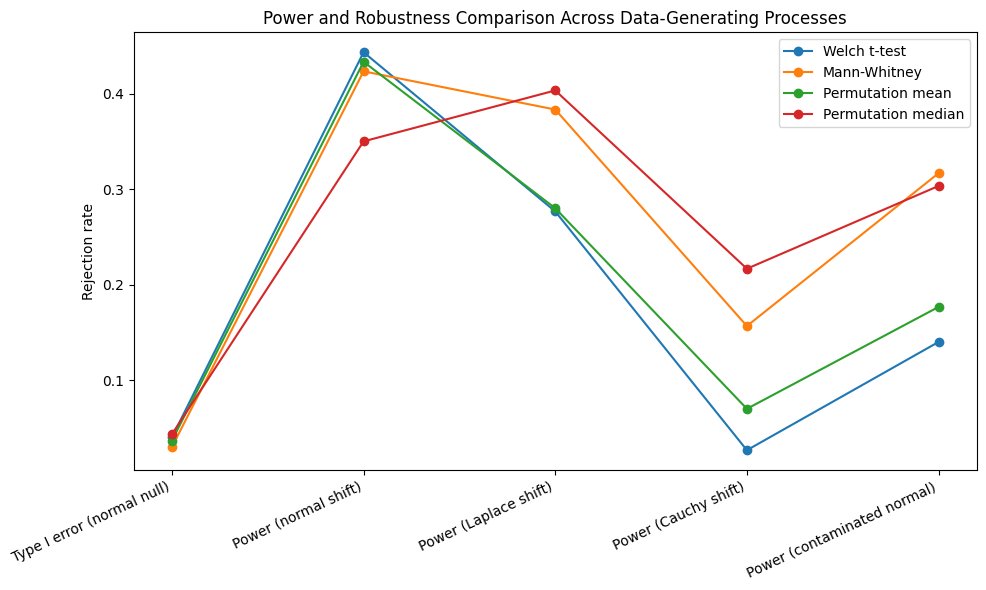

In [10]:
plot_df = summary.set_index("method")

plt.figure(figsize=(10, 6))
for method in plot_df.index:
    plt.plot(plot_df.columns, plot_df.loc[method], marker="o", label=method)

plt.ylabel("Rejection rate")
plt.title("Power and Robustness Comparison Across Data-Generating Processes")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/power_robustness_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">8. Interpretation</p>

The simulation results illustrate a central lesson of applied statistics:

- When parametric assumptions are favorable, parametric methods can be very efficient.
- As tails become heavier or contamination increases, more robust procedures often become relatively more attractive.
- The choice of test statistic matters even within the permutation framework.
- “Nonparametric” does not mean universally better; it means differently structured and often more robust.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">9. Why simulation is so useful</p>

Simulation does not replace theory, but it complements it.

It is especially valuable when:
- methods are difficult to compare analytically,
- robustness matters,
- finite-sample behavior is more important than asymptotic elegance.

This is one reason simulation studies are such an important part of modern statistics.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">10. Takeaways</p>

This notebook compared several procedures under a range of data-generating processes.

The main lesson is not that one method wins universally. The main lesson is that statistical procedures trade off efficiency, robustness, and sensitivity to different features of the data.

That is one of the deepest ideas in nonparametric statistics and in statistical modeling more generally.